## 导入数据

In [14]:
import scipy.io as scio
from scipy.io import savemat  # 把dict文件保存为mat文件
import numpy as np
from sklearn.metrics import r2_score
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor as GBDT
from sklearn.ensemble import ExtraTreesRegressor as ET
from sklearn.ensemble import RandomForestRegressor as RF
from sklearn.ensemble import AdaBoostRegressor as ADA
from sklearn.gaussian_process import GaussianProcessRegressor as GP
from sklearn.tree import DecisionTreeRegressor as DT
from catboost import CatBoostRegressor as cat
from sklearn.svm import SVR
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from xgboost import XGBRegressor as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
import scipy.io as scio
from scipy.io import savemat
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor as DT
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 数据加载和预处理
dataset = pd.read_excel(r"E:\论文5\C\特征优化\UAV0820.xlsx", na_values=['NA', '?', -999])
print(dataset.isnull().sum())
print(dataset.isin([np.nan, np.inf, -np.inf]).sum())

X, y = dataset.iloc[:,:-1], dataset.iloc[:,-1]
z = 121

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=z)
X_cols = X_train.columns

print("特征列名:", X_cols)
print("训练集形状:", X_train.shape)
print("测试集形状:", X_test.shape)

# 创建并训练决策树模型
#model = DT(max_depth=3, min_samples_split=2, min_samples_leaf=1, random_state=61)
model = xgb(n_estimators=90,max_depth=3,learning_rate=0.091,colsample_bytree=0.7,
            min_child_weight=3,reg_alpha=0.07, reg_lambda=0.9 ,subsample=0.9,random_state=51)
#model = GP(kernel=kernel,alpha=0.01, n_restarts_optimizer=3, random_state=z)
#model =RF(n_estimators=87,max_depth=3, min_samples_split=2, min_samples_leaf=1, max_features=None, random_state=z)
#model =SVR(kernel='rbf', C=40, gamma=0.1 )
#model =LinearRegression()
#model =cat(iterations=144,depth=8,learning_rate=0.181, colsample_bylevel=0.7, min_data_in_leaf=2,l2_leaf_reg=3, random_seed=z, verbose=0, early_stopping_rounds=10 )


model.fit(X_train, y_train)

# 预测
pred1 = model.predict(X_train)
pred2 = model.predict(X_test)

# 计算评估指标
def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mae, mape, r2

mse1, rmse1, mae1, mape1, r2_1 = calculate_metrics(y_train, pred1)
mse2, rmse2, mae2, mape2, r2_2 = calculate_metrics(y_test, pred2)

print("=== 训练集评估指标 ===")
print(f"R2: {r2_1:.4f}, MSE: {mse1:.4f}, RMSE: {rmse1:.4f}, MAE: {mae1:.4f}, MAPE: {mape1:.4f}%")

print("=== 测试集评估指标 ===")
print(f"R2: {r2_2:.4f}, MSE: {mse2:.4f}, RMSE: {rmse2:.4f}, MAE: {mae2:.4f}, MAPE: {mape2:.4f}%")

# 保存结果
train_df = pd.DataFrame({'y_train': y_train, 'y_pred': pred1})
test_df = pd.DataFrame({'y_test': y_test, 'y_pred': pred2})

# 保存到Excel
with pd.ExcelWriter(r"E:\论文5\\C\特征优化\UAV0610预测结果.xlsx") as writer:
    train_df.to_excel(writer, sheet_name='训练集', index=False)
    test_df.to_excel(writer, sheet_name='测试集', index=False)

print("结果已保存到Excel文件")

CI       0
EVI      0
GI       0
GNDVI    0
MSAVI    0
NDVI     0
SPAD     0
dtype: int64
CI       0
EVI      0
GI       0
GNDVI    0
MSAVI    0
NDVI     0
SPAD     0
dtype: int64
特征列名: Index(['CI', 'EVI', 'GI', 'GNDVI', 'MSAVI', 'NDVI'], dtype='object')
训练集形状: (140, 6)
测试集形状: (60, 6)
=== 训练集评估指标 ===
R2: 0.8546, MSE: 0.5211, RMSE: 0.7219, MAE: 0.5587, MAPE: 0.9437%
=== 测试集评估指标 ===
R2: 0.0071, MSE: 2.8375, RMSE: 1.6845, MAE: 1.3460, MAPE: 2.2858%
结果已保存到Excel文件


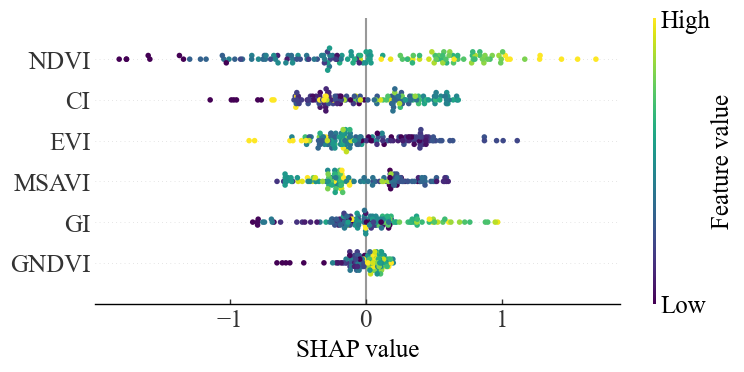

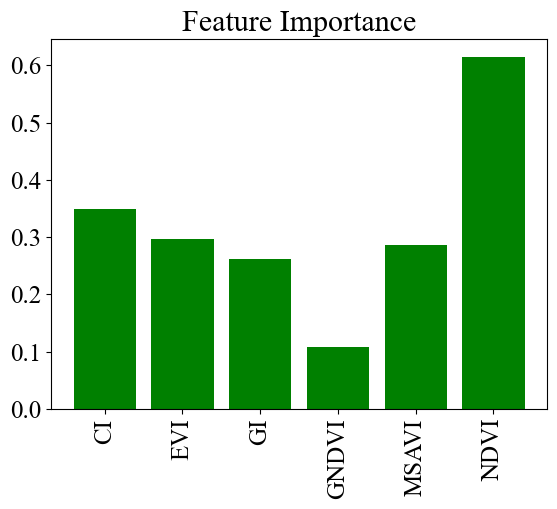

In [16]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# 创建SHAP解释器
explainer = shap.TreeExplainer(model)

# 计算SHAP值
shap_values = explainer.shap_values(X_train)

# 设置全局字体样式
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['font.size'] = 18

# 关键：使用 show=False 并获取 figure 对象
fig = plt.figure(figsize=(7, 6))
feature_label=['CI','EVI','GI','GNDVI','MSAVI','NDVI']
# 创建 SHAP 可视化，指定返回 figure
shap.summary_plot(
    shap_values, 
    X_train,
    feature_names=feature_label,
    show=False,  # 不自动显示
    cmap='viridis'  # 指定配色方案（根据你的需求选择）
)
#配色   viridis  #配色   viridis  Spectral   coolwarm  RdYlGn  RdYlBu  RdBu  RdGy  PuOr  BrBG PRGn  PiYG 
# 获取当前图形
ax = plt.gca()
fig = plt.gcf()

# 调整 colorbar（SHAP summary_plot 的 colorbar 通常在右侧）
# 注意：summary_plot 可能创建多个 axes，colorbar 通常是最后一个
colorbar_axes = [ax for ax in fig.axes if hasattr(ax, 'get_ylabel') and 'Feature value' in str(ax.get_ylabel())]
if colorbar_axes:
    colorbar = colorbar_axes[0]
    colorbar.tick_params(labelsize=18)
    colorbar.set_ylabel('Feature value', fontsize=18)
    for label in colorbar.get_yticklabels():
        label.set_color('black')

# 调整坐标轴样式
plt.xlabel('SHAP value', fontsize=18)

# 设置轴边框样式
for spine in plt.gca().spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)

# 设置刻度样式
plt.tick_params(axis='both', direction='in', width=1, labelsize=18)

# 调整图例（如果存在）
legend = plt.gca().get_legend()
if legend is not None:
    legend.set_fontsize(18)

# 保存图形（确保目录存在）
import os

save_path = r'E:\论文5\c\0820.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
# 直接导出数据画图会自由很多
mean_shap_values = np.abs(shap_values).mean(axis=0)  
features = feature_label
df = pd.DataFrame({'feature_label': feature_label, 'mean_shap_values': mean_shap_values})
with pd.ExcelWriter(r"E:\论文5\C\特征优化\shap 0820.xlsx") as writer:
    df.to_excel(writer, sheet_name='Sheet1', index=False)
    #writer.save()
# 绘制柱状图
plt.bar(features, mean_shap_values, color='green')  # 可以指定任意颜色
plt.xticks(rotation=90)
plt.title('Feature Importance')
plt.show()

In [15]:
import scipy.io as scio
from scipy.io import savemat  # 把dict文件保存为mat文件
import numpy as np
from sklearn.metrics import r2_score
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor as GBDT
from sklearn.ensemble import ExtraTreesRegressor as ET
from sklearn.ensemble import RandomForestRegressor as RF
from sklearn.ensemble import AdaBoostRegressor as ADA
from sklearn.gaussian_process import GaussianProcessRegressor as GP
from sklearn.tree import DecisionTreeRegressor as DT
from catboost import CatBoostRegressor as cat
from sklearn.svm import SVR
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from xgboost import XGBRegressor as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

dataset= pd.read_excel(r"E:\论文4\产量\超参数优化\UAV0908.xlsx",na_values=['NA', '?', -999])
dataset.head()
print(dataset.isnull().sum())  # 检查空值
print(dataset.isin([np.nan, np.inf, -np.inf]).sum())  # 检查NaN和Inf

X,y=dataset.iloc[:,:-1],dataset.iloc[:,-1]
z=105                                    #############################
#scaler = StandardScaler()
#X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=z)
X_cols = X_train.columns
X_train = X_train.values
y_train = y_train.values
X_test = X_test.values
y_test = y_test.values
print("特征列名:", X_cols)
print("X_train类型:", type(X_train))  # 已经是ndarray
print("y_train类型:", type(y_train))  # 仍然是Series，但模型可以接受

# 定义核函数（在models列表之前）
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))
models = [RF(n_estimators=87,max_depth=3, min_samples_split=2, min_samples_leaf=1, max_features=None, random_state=z),
          xgb(n_estimators=80,max_depth=3,learning_rate=0.088,colsample_bytree=0.3, min_child_weight=5,reg_alpha=0.3,  # L1正则
    reg_lambda=0.5 ,subsample=0.8,random_state=z),
         GP(kernel=kernel,alpha=0.01, n_restarts_optimizer=3, random_state=z),
         DT(max_depth=3, min_samples_split=2, min_samples_leaf=1, random_state=z),
         SVR(kernel='rbf', C=40, gamma=0.1 ),
        LinearRegression(),
        cat(iterations=144,depth=8,learning_rate=0.181, colsample_bylevel=0.7, min_data_in_leaf=2,l2_leaf_reg=3, 
        random_seed=z, verbose=0, early_stopping_rounds=10 )
           
    
         ]
X_train_stack = np.zeros((X_train.shape[0], len(models)))
X_test_stack = np.zeros((X_test.shape[0], len(models)))
# 10折stacking
n_folds = 10
kf = KFold(n_splits=n_folds, shuffle=True, random_state=z)
for i, model in enumerate(models):
    X_stack_test_n = np.zeros((X_test.shape[0], n_folds))

    for j, (train_index, test_index) in enumerate(kf.split(X_train)):
        tr_x = X_train[train_index]
        tr_y = y_train[train_index]
        model.fit(tr_x, tr_y)    
        # 生成stacking训练数据集
        X_train_stack[test_index, i] = model.predict(X_train[test_index])
        X_stack_test_n[:, j] = model.predict(X_test)
    # 生成stacking测试数据集
    X_test_stack[:, i] = X_stack_test_n.mean(axis=1)

# 创建DataFrame保存训练集 stacking 数据
train_stack_df = pd.DataFrame(X_train_stack)
train_stack_df.columns = [f'Model_{i+1}' for i in range(len(models))]
train_stack_df['Actual'] = y_train  # 添加真实值

# 创建DataFrame保存测试集 stacking 数据  
test_stack_df = pd.DataFrame(X_test_stack)
test_stack_df.columns = [f'Model_{i+1}' for i in range(len(models))]
test_stack_df['Actual'] = y_test  # 添加真实值

# 保存到Excel文件
with pd.ExcelWriter(r"E:\论文4\产量\超参数优化\Stacking_Data.xlsx") as writer:
    train_stack_df.to_excel(writer, sheet_name='Train_Stacking', index=False)
    test_stack_df.to_excel(writer, sheet_name='Test_Stacking', index=False)

print("Stacking训练集和测试集数据已保存到Excel文件")
print(f"训练集形状: {X_train_stack.shape}")
print(f"测试集形状: {X_test_stack.shape}")




CI       0
MSR      0
NDVI     0
RDVI     0
RVI      0
Yeild    0
dtype: int64
CI       0
MSR      0
NDVI     0
RDVI     0
RVI      0
Yeild    0
dtype: int64
特征列名: Index(['CI', 'MSR', 'NDVI', 'RDVI', 'RVI'], dtype='object')
X_train类型: <class 'numpy.ndarray'>
y_train类型: <class 'numpy.ndarray'>
Stacking训练集和测试集数据已保存到Excel文件
训练集形状: (140, 7)
测试集形状: (60, 7)


In [16]:
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor as GBDT
from sklearn.ensemble import ExtraTreesRegressor as ET
from sklearn.ensemble import RandomForestRegressor as RF
from sklearn.ensemble import AdaBoostRegressor as ADA
from sklearn.gaussian_process import GaussianProcessRegressor as GP
from sklearn.tree import DecisionTreeRegressor as DT
from catboost import CatBoostRegressor as cat
from sklearn.svm import SVR
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from xgboost import XGBRegressor as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

dataset= pd.read_excel(r"E:\论文4\产量\超参数优化\UAV0908.xlsx",na_values=['NA', '?', -999])
dataset.head()
print(dataset.isnull().sum())  # 检查空值
print(dataset.isin([np.nan, np.inf, -np.inf]).sum())  # 检查NaN和Inf

X,y=dataset.iloc[:,:-1],dataset.iloc[:,-1]
z=105                                    #############################
#scaler = StandardScaler()
#X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=z)
X_cols = X_train.columns
X_train = X_train.values
y_train = y_train.values
X_test = X_test.values
y_test = y_test.values
print("特征列名:", X_cols)
print("X_train类型:", type(X_train))  # 已经是ndarray
print("y_train类型:", type(y_train))  # 仍然是Series，但模型可以接受

# 定义核函数（在models列表之前）
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))
models = [RF(n_estimators=87,max_depth=3, min_samples_split=2, min_samples_leaf=1, max_features=None, random_state=z),
          xgb(n_estimators=80,max_depth=3,learning_rate=0.088,colsample_bytree=0.3, min_child_weight=5,reg_alpha=0.3,  # L1正则
    reg_lambda=0.5 ,subsample=0.8,random_state=z),
         GP(kernel=kernel,alpha=0.01, n_restarts_optimizer=3, random_state=z),
         DT(max_depth=3, min_samples_split=2, min_samples_leaf=1, random_state=z),
         SVR(kernel='rbf', C=40, gamma=0.1 ),
        LinearRegression(),
        cat(iterations=144,depth=8,learning_rate=0.181, colsample_bylevel=0.7, min_data_in_leaf=2,l2_leaf_reg=3, 
        random_seed=z, verbose=0, early_stopping_rounds=10 )
           
    
         ]
X_train_stack = np.zeros((X_train.shape[0], len(models)))
X_test_stack = np.zeros((X_test.shape[0], len(models)))
# 10折stacking
n_folds = 10
kf = KFold(n_splits=n_folds, shuffle=True, random_state=z)
for i, model in enumerate(models):
    X_stack_test_n = np.zeros((X_test.shape[0], n_folds))

    for j, (train_index, test_index) in enumerate(kf.split(X_train)):
        tr_x = X_train[train_index]
        tr_y = y_train[train_index]
        model.fit(tr_x, tr_y)    
        # 生成stacking训练数据集
        X_train_stack[test_index, i] = model.predict(X_train[test_index])
        X_stack_test_n[:, j] = model.predict(X_test)
    # 生成stacking测试数据集
    X_test_stack[:, i] = X_stack_test_n.mean(axis=1)

# 创建DataFrame保存训练集 stacking 数据
train_stack_df = pd.DataFrame(X_train_stack)
train_stack_df.columns = [f'Model_{i+1}' for i in range(len(models))]
train_stack_df['Actual'] = y_train  # 添加真实值

# 创建DataFrame保存测试集 stacking 数据  
test_stack_df = pd.DataFrame(X_test_stack)
test_stack_df.columns = [f'Model_{i+1}' for i in range(len(models))]
test_stack_df['Actual'] = y_test  # 添加真实值

# 保存到Excel文件
with pd.ExcelWriter(r"E:\论文4\产量\超参数优化\Stacking_Data.xlsx") as writer:
    train_stack_df.to_excel(writer, sheet_name='Train_Stacking', index=False)
    test_stack_df.to_excel(writer, sheet_name='Test_Stacking', index=False)

print("Stacking训练集和测试集数据已保存到Excel文件")
print(f"训练集形状: {X_train_stack.shape}")
print(f"测试集形状: {X_test_stack.shape}")


CI       0
MSR      0
NDVI     0
RDVI     0
RVI      0
Yeild    0
dtype: int64
CI       0
MSR      0
NDVI     0
RDVI     0
RVI      0
Yeild    0
dtype: int64
特征列名: Index(['CI', 'MSR', 'NDVI', 'RDVI', 'RVI'], dtype='object')
X_train类型: <class 'numpy.ndarray'>
y_train类型: <class 'numpy.ndarray'>
Stacking训练集和测试集数据已保存到Excel文件
训练集形状: (140, 7)
测试集形状: (60, 7)


In [3]:
model_second = xgb(n_estimators=80, max_depth=3,learning_rate=0.09,colsample_bytree=0.3, min_child_weight=3
                   ,reg_alpha=0.3,reg_lambda=0.5 ,subsample=0.8,random_state=34)#@@@23 34 72 123
model_second.fit(X_train_stack,y_train)
pred1 = model_second.predict(X_train_stack)
pred2 = model_second.predict(X_test_stack)
mse1 = mean_squared_error(y_train, pred1)
mse2 = mean_squared_error(y_test, pred2)
print("训练R2:", r2_score(y_train, pred1),"mse:", mean_squared_error(y_train, pred1),"rmse:", np.sqrt(mse1),
      "mae:", mean_absolute_error(y_train, pred1) , "mape:",np.mean(np.abs((y_train - pred1) / y_train)) * 100)
print("测试R2:", r2_score(y_test, pred2),"mse:", mean_squared_error(y_test, pred2),"rmse:", np.sqrt(mse2),
      "mae:", mean_absolute_error(y_test, pred2) , "mape:",np.mean(np.abs((y_test - pred2) / y_test)) * 100)
# 创建一个DataFrame对象
output_df = pd.DataFrame({'Training Set Size': range(1, len(X_train)),
                          })

# 将DataFrame写入Excel文件中的第一个工作表

df = pd.DataFrame({'y_train': y_train, 'y_pred': pred1})
with pd.ExcelWriter(r"E:\论文4\产量\堆叠集成学习模型\0908\A_stackong预测与训练值.xlsx") as writer:
    df.to_excel(writer, sheet_name='Sheet2', index=False)
# 输出测试集预测值和真实值，并保存到Excel文件中
df = pd.DataFrame({'y_test': y_test, 'y_pred': pred2})
with pd.ExcelWriter(r"E:\论文4\产量\堆叠集成学习模型\0908\A_stackong预测与验证值.xlsx") as writer:
    df.to_excel(writer, sheet_name='Sheet1', index=False)
# 输出测试集预测值和真实值，并保存到Excel文件中

NameError: name 'X_train_stack' is not defined

In [21]:
#feature_label=['crim','zn','chas','nox','rm','dis','rad','ptratio','b','lstat']
feature_label=['RF','XGBoost','GP','LR','SVR','DT','CatBoost']

data_train_x_nor= pd.DataFrame(X_train_stack,columns=feature_label)



data_train_x_nor


,RF,XGBoost,GP,LR,SVR,DT,CatBoost
0,1.814172,1.820415,1.853133,1.754733,1.857028,1.856817,1.826099
1,2.008188,2.043943,1.989874,1.963792,2.045487,2.001808,2.035297
2,1.886953,1.853720,1.847400,1.902327,1.867619,1.859060,1.914049
3,2.019142,1.961551,2.022240,2.054185,2.016276,2.041135,1.959040
4,1.931847,1.887964,1.894392,1.928532,1.929987,1.892456,1.899018
...,...,...,...,...,...,...,...
135,1.865994,1.862730,1.794167,1.840931,1.847486,1.801775,1.844389
136,1.910775,1.876781,1.873235,1.970849,1.969098,1.879045,2.015549
137,1.884905,1.876517,1.889934,1.974964,1.877570,1.887699,1.896695
138,1.864864,1.828293,1.866796,1.853025,1.841094,1.820182,1.790412


In [18]:
# 创建SHAP解释器
explainer = shap.TreeExplainer(model_second)

# 计算SHAP值
shap_values = explainer.shap_values(data_train_x_nor)

#特征标签
#feature_label=['crim','zn','chas','nox','rm','dis','rad','ptratio','b','lstat']
feature_label=['RF','XGBoost','GP','LR','SVR','DT','CatBoost']
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['font.size'] = 4  # 设置字体大小为14
# 现在创建 SHAP 可视化 

#配色   viridis  Spectral   coolwarm  RdYlGn  RdYlBu  RdBu  RdGy  PuOr  BrBG PRGn  PiYG 
shap.summary_plot(shap_values, data_train_x_nor,feature_names=feature_label)

#粉红色点：表示该特征值在这个观察中对模型预测产生了正面影响（增加预测值）
#蓝色点：表示该特征值在这个观察中对模型预测产生了负面影响（降低预测值）
#水平轴（SHAP 值）显示了影响的大小。点越远离中心线（零点），该特征对模型输出的影响越大
#图中垂直排列的特征按影响力从上到下排序。上方的特征对模型输出的总体影响更大，而下方的特征影响较小。
# 最上方的特征（例如 "lstat"）显示了大量的正面和负面影响，表明它在不同的观察值中对模型预测的结果有很大的不同影响。
# 中部的特征（如 "rm" 和 "dis"）也显示出两种颜色的点，但点的分布更集中，影响相对较小。
# 底部的特征（如 "chas" 和 "zn"）对模型的影响最小，且大部分影响较为接近零，表示这些特征对模型预测的贡献较小

XGBoostError: [20:07:47] C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\c_api\c_api_utils.h:125: Check failed: std::accumulate(shape.cbegin(), shape.cend(), static_cast<bst_ulong>(1), std::multiplies<>{}) == chunksize * rows (560 vs. 1120) : 

In [19]:
print(shap_values.shape)
print(data_train_x_nor.shape)

NameError: name 'shap_values' is not defined

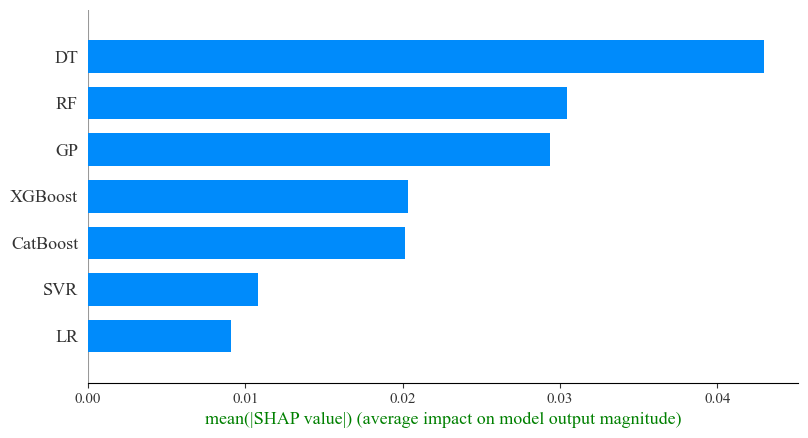

In [28]:
shap.summary_plot(shap_values, data_train_x_nor,feature_names=feature_label,plot_type='bar')
#主要表示绝对重要值的大小，把SHAP value 的样本取了绝对平均值
# 房价预测模型中，lstat（较低状态人口的百分比）和 rm（住宅平均房间数）可能是影响房价的关键因素

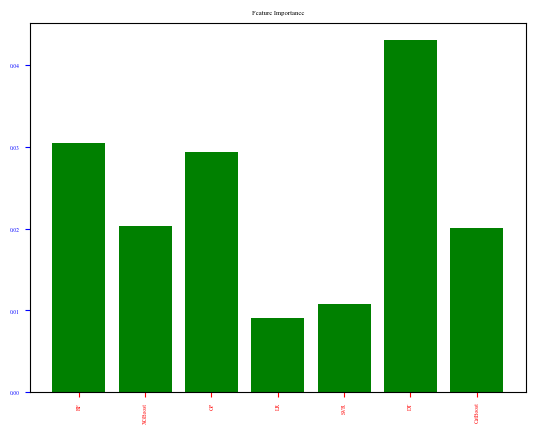

In [30]:

# 直接导出数据画图会自由很多
mean_shap_values = np.abs(shap_values).mean(axis=0)  
features = feature_label
df = pd.DataFrame({'feature_label': feature_label, 'mean_shap_values': mean_shap_values})
with pd.ExcelWriter(r"E:\论文4\产量\SHAP\shap值.xlsx") as writer:
    df.to_excel(writer, sheet_name='Sheet1', index=False)
    #writer.save()
# 绘制柱状图
plt.bar(features, mean_shap_values, color='green')  # 可以指定任意颜色
plt.xticks(rotation=90)
plt.title('Feature Importance')
plt.show()


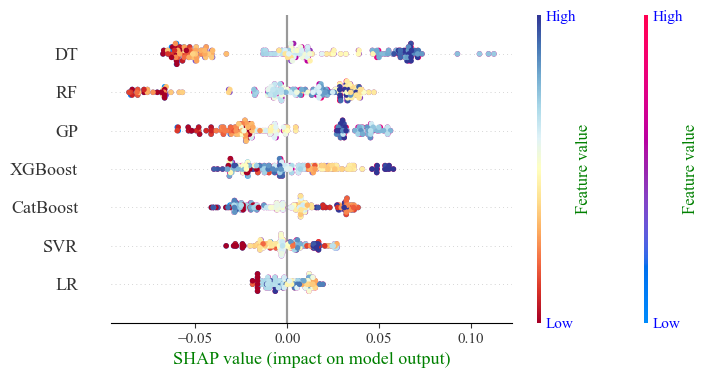

In [31]:
# 创建SHAP解释器
explainer = shap.TreeExplainer(model_second)

# 计算SHAP值
shap_values = explainer.shap_values(data_train_x_nor)


#特征标签
shap.summary_plot(shap_values, data_train_x_nor,feature_names=feature_label,show=False)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['font.size'] = 24  # 设置字体大小为14
# 现在创建 SHAP 可视化 

#配色   viridis  Spectral   coolwarm  RdYlGn  RdYlBu  RdBu  RdGy  PuOr  BrBG PRGn  PiYG 
shap.summary_plot(shap_values, data_train_x_nor,feature_names=feature_label,cmap='RdYlBu')


# 显示图形

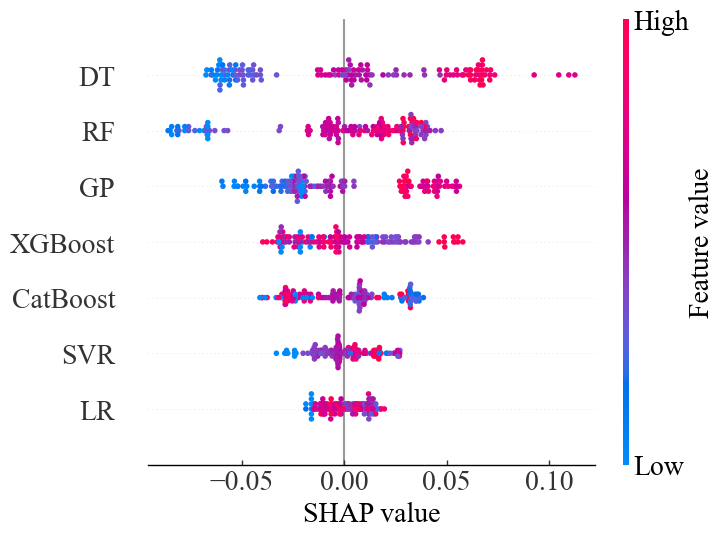

In [45]:
# 导出高质量的图片
# 创建SHAP解释器
explainer = shap.TreeExplainer(model_second)

# 计算SHAP值
shap_values = explainer.shap_values(data_train_x_nor)

# 可视化SHAP值

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['font.size'] = 20  # 设置字体大小为12
# 现在创建 SHAP 可视化
#配色   viridis  #配色   viridis  Spectral   coolwarm  RdYlGn  RdYlBu  RdBu  RdGy  PuOr  BrBG PRGn  PiYG 
shap.summary_plot(shap_values, data_train_x_nor,feature_names=feature_label,show=False)


#------------------------------------SHAP value-------------------------------------
# 获取当前图形的colorbar  
colorbar = plt.gcf().get_axes()[1]  
colorbar.tick_params(labelsize=20)  # 调整colorbar的标签字体大小  

# 调整colorbar的标题和字体大小  
colorbar.set_label('Feature value')  # 设置colorbar的标题  
colorbar.yaxis.label.set_fontsize(20)  # 设置colorbar标题的字体大小 
#colorbar.set_label('Feature value', fontsize=16)  # 设置colorbar的标题和字体大小

# 修改colorbar的颜色  
for label in colorbar.get_yticklabels():  
    label.set_color('black')  # 将colorbar标签颜色设置为黑色  



plt.gcf().set_size_inches(7, 6)
# 修改X轴标题  
plt.xlabel('SHAP value',fontsize=20) 
# 修改X轴和Y轴的颜色和线宽  
plt.gca().spines['bottom'].set_color('black')  # 设置X轴颜色为黑色  
plt.gca().spines['bottom'].set_linewidth(1)  # 设置X轴线宽为1.5   2磅
plt.gca().spines['left'].set_color('black')  # 设置Y轴颜色为黑色  
plt.gca().spines['left'].set_linewidth(1)  # 设置Y轴线宽为1.5  
plt.tick_params(axis='x', direction='in', width=1)  # direction='in'表示向内  
# 调整X轴刻度字体字号大小  
plt.tick_params(axis='x', labelsize=20)  # labelsize设置字体大小
plt.tick_params(axis='y', labelsize=20)  # labelsize设置字体大小
# 获取当前图形中的图例并调整其大小  
if plt.gcf().axes:  
    for ax in plt.gcf().axes:  
        if ax.get_legend() is not None:  # 如果存在图例  
            ax.legend(fontsize=20, loc='best', frameon=True, shadow=True)  # 自定义图例样式  
#        

# 保存图形为高质量的图片文件
plt.savefig('shap value.png', dpi=300, bbox_inches='tight')

# 显示图形

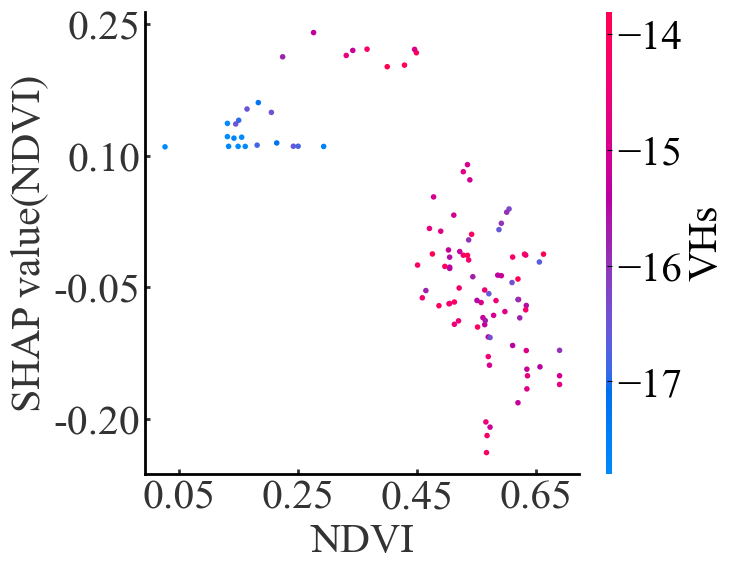

In [12]:
# 设置字体为新罗马并调整字体大小
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['font.size'] = 30 # 设置字体大小为14 SimSun Times New Roman

# 创建 SHAP dependence plot，并修改配色方案为 'RdBu'

# shap.dependence_plot('Feature 1', shap_values, data_train_x_nor, interaction_index='Feature 2')
#shap.dependence_plot('lstat', shap_values, data_train_x_nor1, interaction_index='b')
shap.dependence_plot('NDVI', shap_values, data_train_x_2, interaction_index='VHs',show=False)#['VV','VVs','VH','VHs','NDVI','VHs/VVs']

#shap.summary_plot(shap_values, data_train_x_nor,feature_names=feature_label,show=False)

#--------------------------------------VV--VVs-----------------------------------------------------------
# 获取当前图形的colorbar  
colorbar = plt.gcf().get_axes()[1]  
colorbar.tick_params(labelsize= 30)  # 调整colorbar的标签字体大小  

# 调整colorbar的标题和字体大小  
#colorbar.set_label('0')  # 设置colorbar的标题  
colorbar.yaxis.label.set_fontsize(30)  # 设置colorbar标题的字体大小 
#colorbar.set_label('Feature value', fontsize=16)  # 设置colorbar的标题和字体大小

# 调整colorbar与X轴的距离  
#colorbar.yaxis.set_label_coords(12.15, 0.5)  # 调整colorbar标题的位置  


#colorbar刻度向内
colorbar.tick_params(direction='in')

 
 


colorbar.set_aspect(20) #VHs/VVs=180; NDVI=160/180; VV=15; VVs=18; VH/s=20
    
plt.gcf().set_size_inches(7, 6)
# 修改Xy轴标题  
plt.ylabel('SHAP value(NDVI)',fontsize=30) 
plt.xlabel('NDVI',fontsize=30) 

# 修改X轴和Y轴的颜色和线宽  
plt.gca().spines['bottom'].set_color('black')  # 设置X轴颜色为黑色  
plt.gca().spines['bottom'].set_linewidth(2)  # 设置X轴线宽为1.5  
plt.gca().spines['left'].set_color('black')  # 设置Y轴颜色为黑色  
plt.gca().spines['left'].set_linewidth(2)  # 设置Y轴线宽为1.5  
plt.tick_params(axis='x', direction='in', width=2)  # direction='in'表示向内 
plt.tick_params(axis='y', direction='in', width=2)  # direction='in'表示向内 
# 调整Xy轴刻度字体字号大小  
plt.tick_params(axis='x', labelsize=30)  # labelsize设置字体大小
plt.tick_params(axis='y', labelsize=30)  # labelsize设置字体大小

# 设置XY轴坐标刻度  
plt.xticks(ticks=[0.05, 0.25, 0.45, 0.65], labels=['0.05','0.25', '0.45','0.65'])  
plt.yticks(ticks=[-0.20, -0.05, 0.10, 0.25], labels=['-0.20', '-0.05', '0.10', '0.25'])  

# 获取当前图形中的图例并调整其大小  
if plt.gcf().axes:  
    for ax in plt.gcf().axes:  
        if ax.get_legend() is not None:  # 如果存在图例  
            ax.legend(fontsize=30, loc='best', frameon=True, shadow=True)  # 自定义图例样式  


#==============================================================================--  
# 保存图形为高质量的图片文件
plt.savefig('NDVI-VHs.png', dpi=300, bbox_inches='tight', pad_inches=0.1)
#==============================================================================-- 
#解释
# 负相关关系：lstat 对模型预测有显著的负面影响。高 lstat 值显著降低了预测值。也就是说，随着 lstat 的增加，目标变量 b 的预测值逐渐降低。
# 影响的程度：lstat 的值在 0 到 2 的范围内，SHAP 值有较大的变化。这表明，在这个范围内，lstat 对模型预测的影响最大。

# 特征重要性：这个图显示了 lstat 是一个对模型预测非常重要的特征。理解 lstat 对预测的具体影响有助于进一步优化模型，或者在数据预处理中针对性地处理 lstat 的数据。
# 模型优化：通过这种依赖性图，可以更好地理解模型对特定特征值范围的敏感性，从而可以在这些范围内进行更精细的数据采集和模型调整

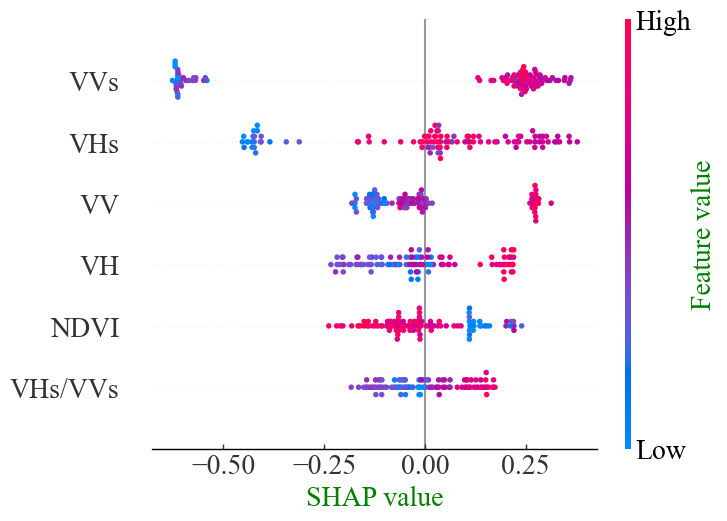

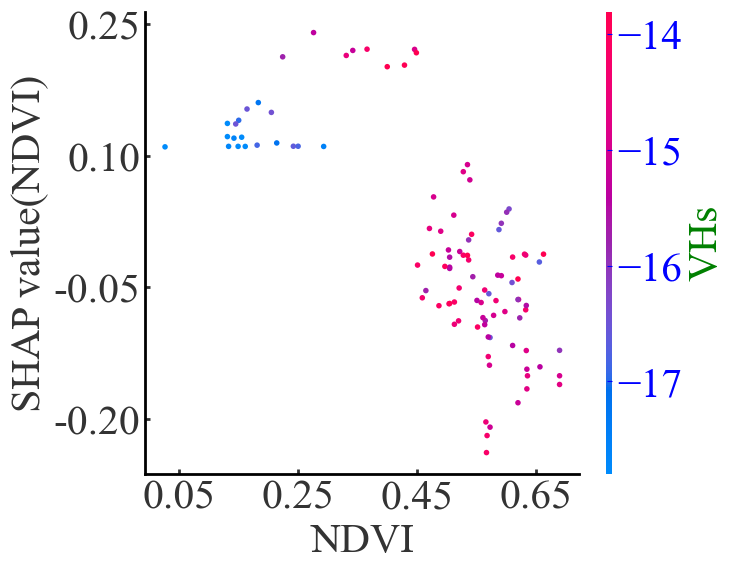

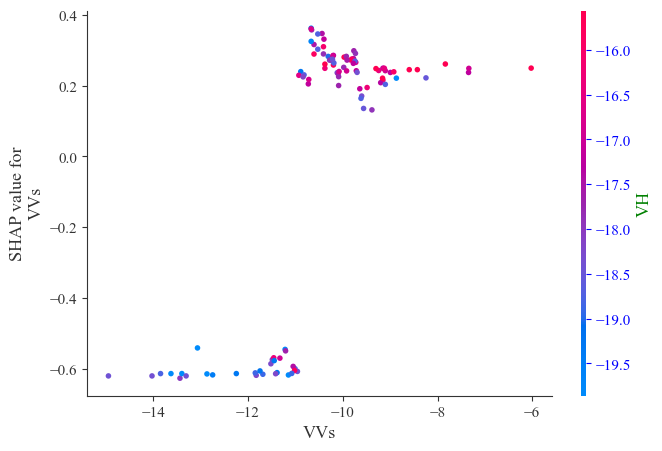

In [668]:
# 设置字体为新罗马并调整字体大小
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['font.size'] = 20  # 设置字体大小为14
# 创建 SHAP dependence plot，并修改配色方案为 'RdBu'
#shap.dependence_plot('nox', shap_values, data_train_x_nor1, interaction_index='dis', cmap='RdBu')
shap.dependence_plot('VVs', shap_values, data_train_x_2, interaction_index='VH')#['VV','VVs','VH','VHs','NDVI','VHs/VVs']
plt.savefig('1.png', dpi=300, bbox_inches='tight', pad_inches=0.1)
# "DIS" 特征的影响分布：图中显示，较小的 "DIS" 值通常与 SHAP 值的负影响相关，即当 "DIS" 较小，即距离中心地区更近时，可能对模型预测产生降低影响。而 "DIS" 较大时，对模型预测的影响较小或无显著影响。
# 颜色的变化：红色点集中在 "DIS" 的中低值区域，可能表示在距离中心地区较近的地方，高税率对预测结果的负面影响更为显

In [15]:
#样本局部解释图
#设置全局字体大小  
plt.rcParams['font.size'] = 34  # 修改为你想要的大小  
# force_plot = shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0, :])
#force_plot1 = shap.force_plot(explainer.expected_value, shap_values[0,:], data_train_x_nor1.iloc[0,:],feature_label,matplotlib=True, show=False)
force_plot1 = shap.force_plot(explainer.expected_value, shap_values[0,:], data_train_x_2.iloc[0,:],feature_label,
                               show=False, text_rotation=0, text_color='black', text_kw={'fontsize':14, 'family':'Arial'})  
# 显示图形
#plt.sho
# 调整图形大小
# plt.gcf().set_size_inches(10, 8)

# 修改Xy轴标题  
#plt.ylabel(fontsize=30) 
#plt.xlabel(fontsize=30) 
# 设置字体为新罗马并调整字体大小
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['font.size'] = 30 # 设置字体大小为14 SimSun Times New Roman

# 修改X轴和Y轴的颜色和线宽  
plt.gca().spines['bottom'].set_color('black')  # 设置X轴颜色为黑色  
plt.gca().spines['bottom'].set_linewidth(5)  # 设置X轴线宽为1.5  
plt.gca().spines['left'].set_color('black')  # 设置Y轴颜色为黑色  
plt.gca().spines['left'].set_linewidth(2)  # 设置Y轴线宽为1.5  
plt.tick_params(axis='x', direction='in', width=2)  # direction='in'表示向内 
plt.tick_params(axis='y', direction='in', width=2)  # direction='in'表示向内 
# 调整Xy轴刻度字体字号大小  
plt.tick_params(axis='x', labelsize=30)  # labelsize设置字体大小
plt.tick_params(axis='y', labelsize=30)  # labelsize设置字体大小









# 保存图形为高质量的图片w()文件
plt.savefig('样本局部解释2.png', dpi=300, bbox_inches='tight', pad_inches=0.1)

# 这张图是 SHAP 的 force_plot，用于显示一个单一预测的详细特征贡献,每个特征对最终预测值的贡献以箭头的形式显示，箭头长度和颜色表示该特征的影响程度和方向

NameError: name 'data_train_x_2' is not defined

In [697]:
shap_values[0,:]

array([-0.0350632 ,  0.35762616, -0.06997572,  0.37781342,  0.24002342,
       -0.10670145])

In [698]:
# force_plot = shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0, :])
force_plot1 = shap.force_plot(explainer.expected_value, np.mean(shap_values, axis=0), np.mean(data_train_x_2, axis=0),feature_label,matplotlib=True, show=False)
# 显示图形
# plt.show()
# 调整图形大小
# plt.gcf().set_size_inches(10, 8)

# 保存图形为高质量的图片文件
plt.savefig('样本局部解释.png', dpi=300, bbox_inches='tight', pad_inches=0.1)


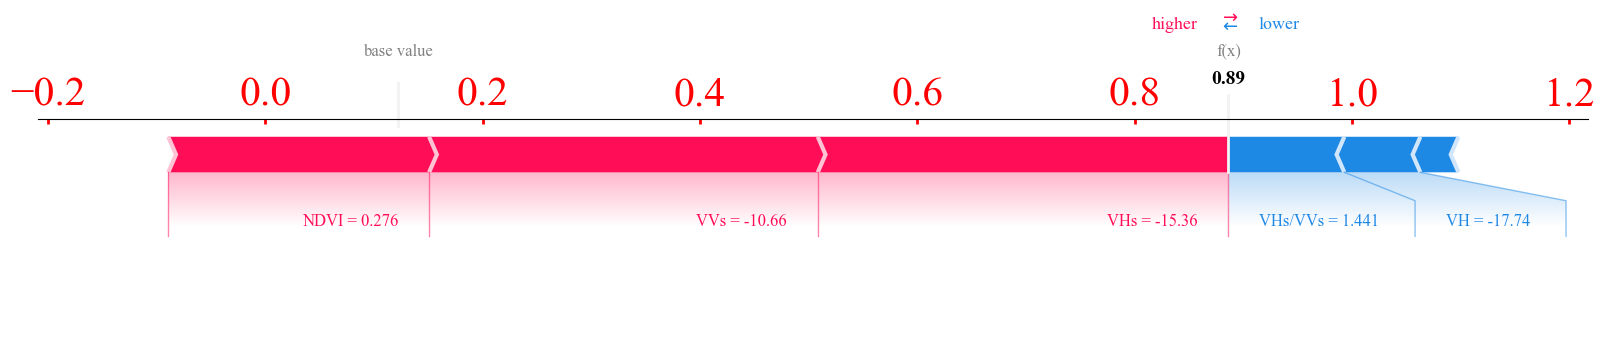

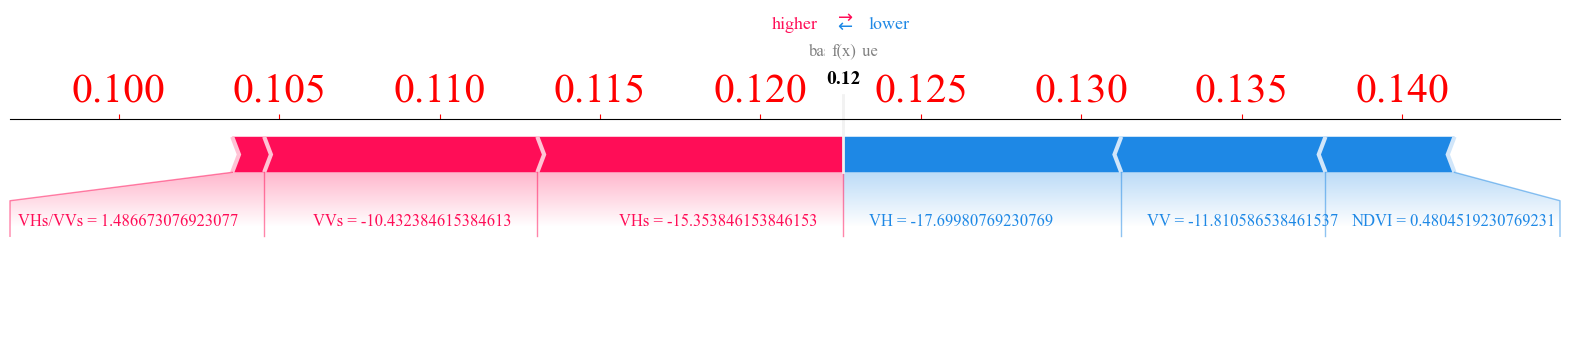

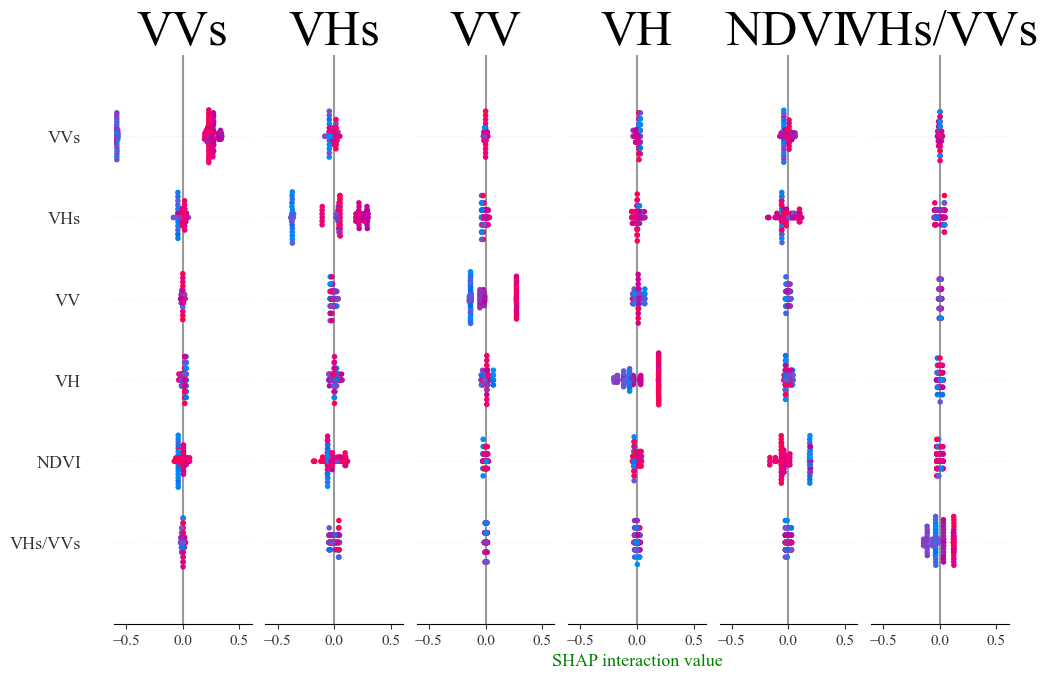

In [693]:
#相互作用图
shap_interaction_values = explainer.shap_interaction_values(data_train_x_nor1)
shap.summary_plot(shap_interaction_values, data_train_x_nor1)

<Figure size 640x480 with 0 Axes>

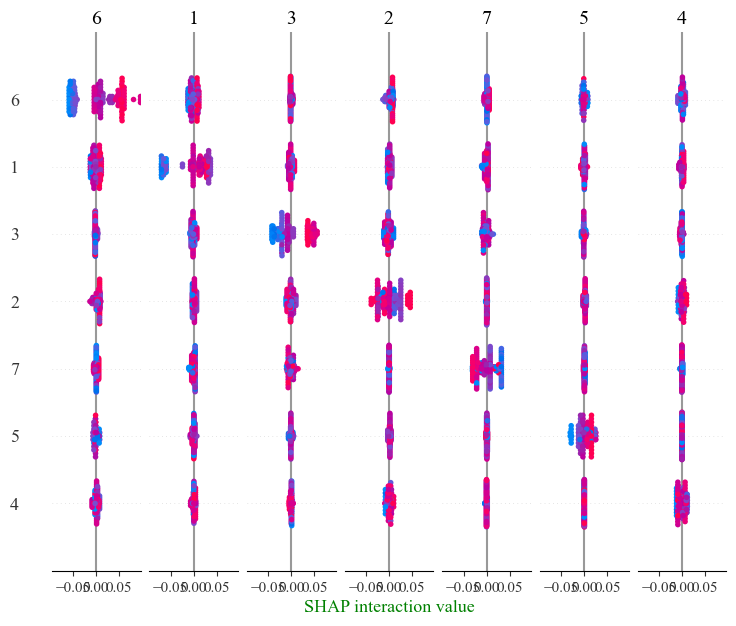

In [34]:
shap_interaction_values = explainer.shap_interaction_values(data_train_x_nor)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['font.size'] = 12  # 设置字体大小为12
# 现在创建 SHAP 可视化
#配色   viridis  
# shap.summary_plot(shap_values, data_train_x_nor,feature_names=feature_label,cmap='Spectral',show=False)



# 修改全局配色方案
plt.set_cmap('viridis')  # 选择你喜欢的配色方案

# 绘制相互作用图
shap.summary_plot(shap_interaction_values, data_train_x_nor1, plot_type='dot', cmap='coolwarm',show=False)

plt.gcf().set_size_inches(7, 6)

# 保存图形为高质量的图片文件
plt.savefig('样本.png', dpi=300, bbox_inches='tight')

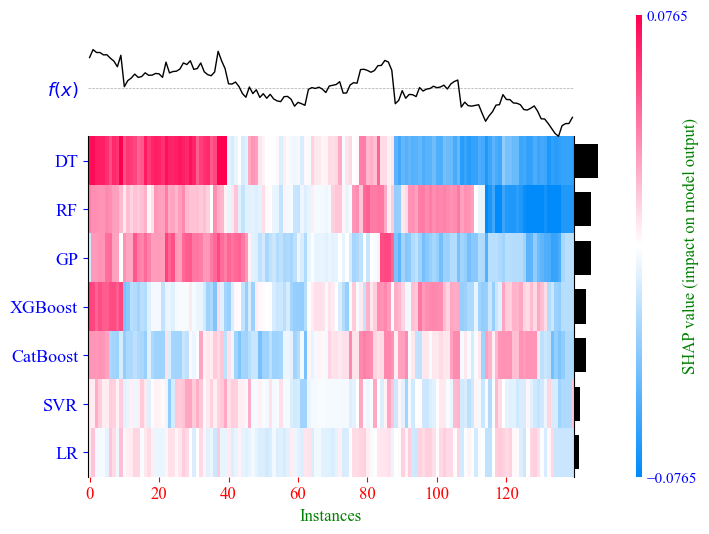

<Axes: xlabel='Instances'>

In [36]:

shap_values2 = explainer(data_train_x_nor)
# 将 shap_values 转换为 DataFrame

# 绘制热力图

shap.plots.heatmap(shap_values2)

# 上侧是模型的输出，右侧是目标全局重要性

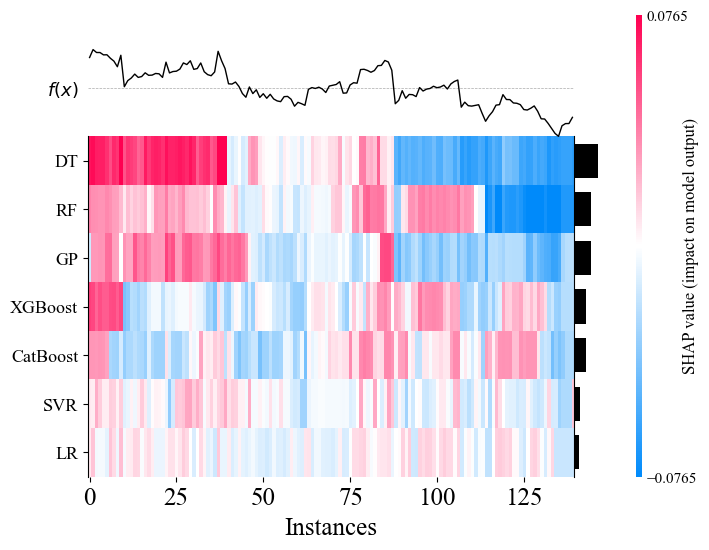

<Figure size 640x480 with 0 Axes>

In [44]:
# 设置字体和颜色
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': 'Times New Roman',
    'font.size': 18,  # 改变字体大小
    'text.color': 'black',  # 修改文字颜色
    'axes.labelcolor': 'black',  # 修改轴标签颜色
    'xtick.color': 'black',  # 修改x轴刻度颜色
    'ytick.color': 'black'  # 修改y轴刻度颜色
})

# 确保 shap_values2 是 DataFrame 格式，并已正确计算
shap.plots.heatmap(shap_values2)

# 显示图表
plt.show()
# 保存为PDF（矢量图，适合论文）
plt.savefig(r"E:\论文4\产量\SHAP_Heatmap.pdf", bbox_inches='tight')
# plt.savefig('shap_heatmap.png', dpi=300, bbox_inches='tight')  # 高分辨率保存
# 保存为SVG（矢量图）
plt.savefig(r"E:\论文4\产量\SHAP_Heatmap.svg", bbox_inches='tight')

# 保存为TIFF（高质量位图）
plt.savefig(r"E:\论文4\产量\SHAP_Heatmap.tiff", dpi=300, bbox_inches='tight')

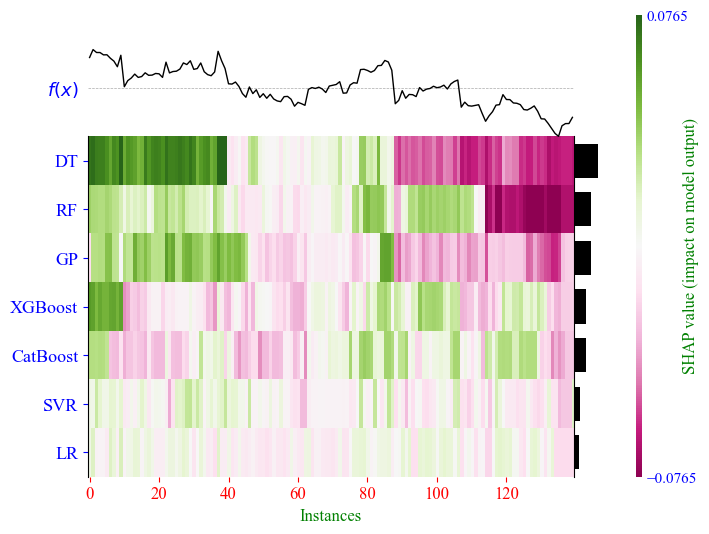

In [38]:
# 设置字体和颜色
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': 'Times New Roman',
    'font.size': 12,  # 改变字体大小
    'text.color': 'black',  # 修改文字颜色
    'axes.labelcolor': 'green',  # 修改轴标签颜色
    'xtick.color': 'red',  # 修改x轴刻度颜色
    'ytick.color': 'blue'  # 修改y轴刻度颜色
})

# 确保 shap_values2 是 DataFrame 格式，并已正确计算
shap.plots.heatmap(shap_values2, cmap='PiYG')

# 显示图表
plt.show()

# plt.savefig('shap_heatmap.png', dpi=300, bbox_inches='tight')  # 高分辨率保存

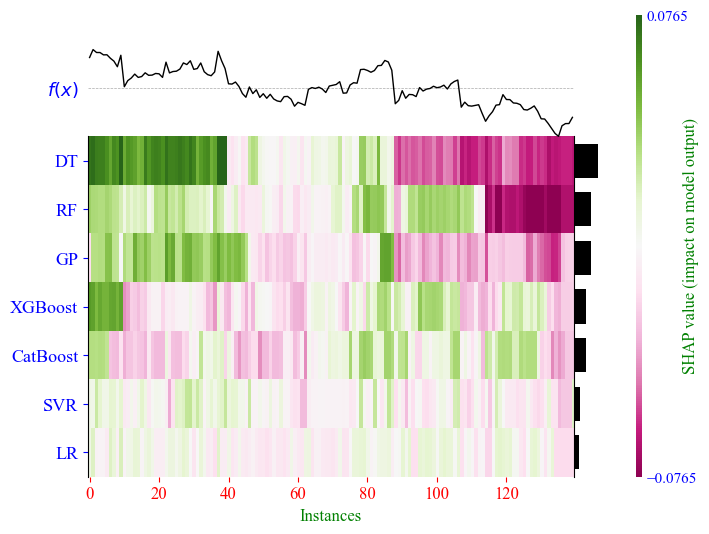

<Figure size 640x480 with 0 Axes>

In [39]:
# 保存为高清图片
# 设置字体和颜色
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': 'Times New Roman',
    'font.size': 12,  # 改变字体大小
    'text.color': 'black',  # 修改文字颜色
    'axes.labelcolor': 'green',  # 修改轴标签颜色
    'xtick.color': 'red',  # 修改x轴刻度颜色
    'ytick.color': 'blue'  # 修改y轴刻度颜色
})

# 确保 shap_values2 是 DataFrame 格式，并已正确计算
shap.plots.heatmap(shap_values2, cmap='PiYG',show=False)
plt.show()
# plt.gcf().set_size_inches(7, 6)
# plt.savefig('shap_heatmap1.png')
plt.savefig('shap_heatmap2.png', dpi=300, bbox_inches='tight')  # 高分辨率保存